In [6]:
import ollama
from ollama import WebSearchResponse
from src.utils.models import get_model
import os
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field, model_validator

from src.config import ROOT_DIR
from src.utils.helpers import get_prompt_template
import json
from typing import Literal
from src.config import ROOT_DIR
from src.utils.helpers import get_prompt_template, get_today_str
import dotenv

dotenv.load_dotenv()

/Users/gaurav/Documents/projects/OpenDeepResearch/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:26: UserWarning:

Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.



True

In [5]:
model = get_model()

In [6]:
data_path = "/Users/gaurav/Documents/projects/OpenDeepResearch/data/research_notes_data.json"
with open(data_path, "r") as f:
    data = json.load(f)

# Indexing each item
research_notes = data[0]["research_notes"]
research_brief = data[0]["research_brief"]
for i, (key, value) in enumerate(research_notes.items(), 1):
    value["index"] = i

In [7]:
research_findings = ""
for i, (key, value) in enumerate(research_notes.items(), 1):
    research_findings += f"{[i]}. {key}: {value['description']}\n"



In [8]:
file_names = list(research_notes.keys())

SectionMode = Literal["writing_instruction", "actual_content"]



class ReportPlan(BaseModel):
    section_name: str = Field(
        description="The name of the section (H1 level, do not include '#')."
    )

    section_mode: SectionMode = Field(
        description="Mode of the section: either 'writing_instruction' or 'actual_content'."
    )

    writing_instruction: str = Field(
        description=(
            "Direct, imperative instructions for the section writer. "
            "Must be non-empty if section_mode is 'writing_instruction'. "
            "Must be empty string if section_mode is 'actual_content'."
        )
    )

    actual_content: str = Field(
        description=(
            "Publication-ready final content of the section. "
            "Must be non-empty if section_mode is 'actual_content'. "
            "Must be empty string if section_mode is 'writing_instruction'."
        )
    )

    source_file_name_list: list[Literal[*file_names]] = Field(
        description=(
            "List of source file names directly required for this section. "
            "Must be non-empty when section_mode is 'writing_instruction'. "
            "Must be an empty list [] when section_mode is 'actual_content'."
        )
    )

    @model_validator(mode="after")
    def validate_mode_constraints(self):
        if self.section_mode == "writing_instruction":
            if not self.writing_instruction.strip():
                raise ValueError("writing_instruction must be non-empty when section_mode is 'writing_instruction'.")
            if self.actual_content.strip():
                raise ValueError("actual_content must be empty when section_mode is 'writing_instruction'.")
            if not self.source_file_name_list:
                raise ValueError("source_file_name_list must be non-empty when section_mode is 'writing_instruction'.")

        elif self.section_mode == "actual_content":
            if not self.actual_content.strip():
                raise ValueError("actual_content must be non-empty when section_mode is 'actual_content'.")
            if self.writing_instruction.strip():
                raise ValueError("writing_instruction must be empty when section_mode is 'actual_content'.")
            if self.source_file_name_list:
                raise ValueError("source_file_name_list must be empty when section_mode is 'actual_content'.")

        return self


class ReportPlanner(BaseModel):
    report_plan: list[ReportPlan] = Field(
        description="Ordered list of report sections forming the complete structured report plan."
    )


structured_model = model.with_structured_output(ReportPlanner)


In [9]:
prompt_template_path = os.path.join(ROOT_DIR, "src", "deep_research_agent", "prompts", "report_writing_planner.jinja")
prompt_template = get_prompt_template(prompt_template_path)
prompt = prompt_template.render(
    research_brief=research_brief,
    research_findings=research_findings,
    date=get_today_str()
)
result = structured_model.invoke([SystemMessage(content=prompt)])


In [83]:
result.model_dump()

{'report_plan': [{'section_name': 'Introduction',
   'section_mode': 'actual_content',
   'writing_instruction': '',
   'actual_content': 'Toronto’s coffee culture is vibrant and diverse, with cafés ranging from artisanal roasters to community hubs. This report presents a curated list of notable coffee shops across all Toronto neighborhoods, detailing each shop’s address, operating hours, signature specialty drinks, typical price range, overall ambiance, and aggregated customer reviews and ratings. The information is compiled from primary sources such as official shop websites and reputable review platforms, ensuring accuracy and relevance.',
   'source_file_name_list': []},
  {'section_name': 'Neighborhood Distribution and Context',
   'section_mode': 'writing_instruction',
   'writing_instruction': 'Define the geographic scope of Toronto neighborhoods represented in the curated list. Use the curated list of 16-19 shops [1], the Th3rdwave coffee shop map [3], and the top 30 cafés by n

In [84]:
len(prompt.split())

1163

In [10]:
for section in result.report_plan:
    print(f"Section: {section.section_name}")
    print(f"Section mode: {section.section_mode}")
    print(f"Description: {section.actual_content}")
    print(f"Writing instruction: {section.writing_instruction}")
    print(f"Source file name list: {section.source_file_name_list}")
    print("\n")


Section: Introduction
Section mode: actual_content
Description: This report presents a curated list of notable coffee shops across Toronto’s neighborhoods, compiled from primary and reputable sources. The list includes address, operating hours, signature specialty drinks, typical price range, ambiance, and aggregated customer reviews and ratings. The report is organized into sections that detail the data compilation process, neighborhood-based comparative analysis, and a summary of key findings, concluding with actionable insights for coffee enthusiasts and visitors.
Writing instruction: 
Source file name list: []


Section: Data Compilation and Methodology
Section mode: writing_instruction
Description: 
Writing instruction: Define key concepts: curated list, operating hours, signature drinks, price range, ambiance, customer reviews. Organize into subsections: 1) Source Selection, 2) Data Extraction, 3) Data Consolidation, 4) Review Aggregation. Provide a comparison table covering shop

## Section Write

In [105]:
section_names = "\n".join([f"{i+1}. {section.section_name}" for i, section in enumerate(result.report_plan)])
cur_section_name = result.report_plan[1].section_name
cur_section_instruction = result.report_plan[1].writing_instruction
prev_section_text = result.report_plan[0].actual_content
source_file_names = result.report_plan[1].source_file_name_list
source_text =""
for source_file_name in source_file_names:
    source_text += f"SOURCE INDEX {research_notes[source_file_name]["index"]}:\n{research_notes[source_file_name]["content"]}\n---\n\n"



In [106]:
prompt_template_path = os.path.join(ROOT_DIR, "src", "deep_research_agent", "prompts", "section_writer.jinja")
prompt_template = get_prompt_template(prompt_template_path)
prompt = prompt_template.render(
    research_brief=research_brief,
    section_names=section_names,
    cur_section=cur_section_name,
    section_description=cur_section_instruction,
    previous_section=prev_section_text,
    source_content=source_text
)
result = model.invoke([SystemMessage(content=prompt)])

In [109]:
print(result.content)

# Neighborhood Distribution and Context

## 1. Overview of Neighborhood Coverage
The curated list of 16‑19 coffee shops from Toronto Times [index_1] spans a range of neighborhoods that are also highlighted in the Th3rdwave map [index_3] and the top‑30 cafés by neighbourhood article [index_5]. The neighborhoods represented are:

| Neighborhood | Number of Notable Shops |
|--------------|------------------------|
| Financial District (Downtown) | 16 |
| Queen West (Old Toronto) | 2 |
| Distillery District | 1 |
| North York | 1 |
| East York | 3 |
| Entertainment District | 1 |
| Leslieville | 1 |

These figures reflect the concentration of specialty coffee venues in the city’s core, with a gradual spread into adjacent districts.

## 2. Distribution of Notable Coffee Shops
A comparison table below lists each neighborhood, the count of notable shops from the curated list, and a representative selection of shop names that exemplify the local coffee culture.

| Neighborhood | Number of Nota

SOURCE INDEX 1:
Title:
The Fix: 19 Coffee Shops in Toronto Worth Getting Out of Bed For - Toronto Times

Summary:
The article, published on 10 September 2025, profiles 16 of Toronto’s most celebrated coffee shops, highlighting why each deserves a spot on a city‑wide caffeine map. Each entry lists a signature brew, the shop’s vibe, key addresses, and the author’s rationale for inclusion. Highlights include:
- **De Mello** (8 Spadina Ave, 2489 Yonge St) – renowned for its Rwanda Tumba Washed Red Bourbon, praised for technical obsession and commercial success.
- **Pilot Coffee Roasters** (Union Station, PATH) – the backbone of Toronto’s wholesale network, exemplifying scalable specialty coffee.
- **Dark Horse Espresso Bar** (630 Queen St E, 215 Spadina Ave) – a reliable, large‑format spot for remote workers.
- **Jimmy’s Coffee** (166 McCaul St, 191 Baldwin St) – a hipster staple balancing independent feel with multiple locations.
- **Boxcar Social** (1208 Yonge St, 235 Queens Quay W) – a 

In [3]:
not []

True

In [13]:
with open("/Users/gaurav/Documents/projects/OpenDeepResearch/output/research_report.md", "r") as f:
    content = f.read()
print(content)

# Introduction\n\nThis report provides a comprehensive, evidence‑based overview of all available funding options for a Sri Lankan woman with Canadian permanent residency who intends to pursue the Rotman MBA in Toronto. It synthesizes information from Rotman’s scholarship portal, Canadian federal and provincial loan programs, private‑bank loan products, employer sponsorship schemes, part‑time work and co‑op opportunities, diaspora‑based scholarships, women‑focused fellowships, and other relevant financial aid. The goal is to equip the applicant with a clear, actionable funding strategy that aligns with her savings, tuition requirements, and living‑cost expectations.\n\n# Rotman‑Specific Scholarships, Bursaries, and Awards\n\n## Rotman Scholarship Pool Overview\n- **Total annual value**: >$5 million in scholarships and awards each year【index_3】【index_23】  \n- **Number of awards**: ~⅓ of new students receive entrance awards; additional Dean’s Scholars, in‑program awards, and diversity gra

## Test chart agent code

In [ ]:
code ="""
import plotly.graph_objects as go\nimport pandas as pd\n\\nmonths = ['January','February','March','April','May','June','July','August','September','October','November','December']\\ntemp = [26.5, 26.2, 24.8, 22.1, 18.9, 16.2, 15.4, 16.8, 19.1, 21.5, 23.6, 25.4]\\nrain = [102, 118, 130, 128, 120, 132, 98, 82, 68, 77, 84, 78]\\n\\nfig = go.Figure()\\n\\n# Rainfall bars (secondary y-axis)\\nfig.add_trace(go.Bar(\\n    x=months,\\n    y=rain,\\n    name='Rainfall (mm)',\\n    marker_color='#3498DB',\\n    marker_opacity=0.6,\\n    yaxis='y2'\\n))\\n\\n# Temperature line (primary y-axis)\\nfig.add_trace(go.Scatter(\\n    x=months,\\n    y=temp,\\n    name='Average Temperature (°C)',\\n    mode='lines+markers',\\n    line=dict(color='#E74C3C', width=2),\\n    marker=dict(size=8, color='#E74C3C'),\\n    yaxis='y1'\\n))\\n\\nfig.update_layout(\\n    title=dict(text='Monthly Temperature and Rainfall — Sydney, Australia (2025)', x=0.5, y=0.95, font=dict(size=20)),\\n    xaxis=dict(title='', tickangle=0, showgrid=False, zeroline=False),\\n    yaxis=dict(title='Average Temperature (°C)', titlefont=dict(color='#E74C3C'), tickfont=dict(color='#E74C3C'), showgrid=True, gridcolor='rgba(0,0,0,0.1)', gridwidth=1, griddash='dash'),\\n    yaxis2=dict(title='Rainfall (mm)', titlefont=dict(color='#3498DB'), tickfont=dict(color='#3498DB'), overlaying='y', side='right', showgrid=False),\\n    plot_bgcolor='#FAFAFA',\\n    paper_bgcolor='#FFFFFF',\\n    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5, font=dict(size=12)),\\n    margin=dict(l=60, r=60, t=80, b=60),\\n    shapes=[\\n        dict(type='rect', xref='paper', yref='y', x0=0, x1=1, y0=15, y1=20,\\n             fillcolor='#FFFDE7', opacity=0.5, line=dict(width=0))\\n    ],\\n    annotations=[\\n        dict(text='Cool Season', x=0.5, y=17.5, xref='paper', yref='y', showarrow=False,\\n             font=dict(size=12, color='#000000', style='italic'))\\n    ]\\n)\\n\"}
"""

print(code)


import plotly.graph_objects as go
import pandas as pd
\nmonths = ['January','February','March','April','May','June','July','August','September','October','November','December']\ntemp = [26.5, 26.2, 24.8, 22.1, 18.9, 16.2, 15.4, 16.8, 19.1, 21.5, 23.6, 25.4]\nrain = [102, 118, 130, 128, 120, 132, 98, 82, 68, 77, 84, 78]\n\nfig = go.Figure()\n\n# Rainfall bars (secondary y-axis)\nfig.add_trace(go.Bar(\n    x=months,\n    y=rain,\n    name='Rainfall (mm)',\n    marker_color='#3498DB',\n    marker_opacity=0.6,\n    yaxis='y2'\n))\n\n# Temperature line (primary y-axis)\nfig.add_trace(go.Scatter(\n    x=months,\n    y=temp,\n    name='Average Temperature (°C)',\n    mode='lines+markers',\n    line=dict(color='#E74C3C', width=2),\n    marker=dict(size=8, color='#E74C3C'),\n    yaxis='y1'\n))\n\nfig.update_layout(\n    title=dict(text='Monthly Temperature and Rainfall — Sydney, Australia (2025)', x=0.5, y=0.95, font=dict(size=20)),\n    xaxis=dict(title='', tickangle=0, showgrid=False, zeroli

In [7]:
json.loads(code)

JSONDecodeError: Expecting value: line 2 column 1 (char 1)

In [8]:
from src.deep_research_agent.agents.chart_agent_code_with_tools import ChartAgent

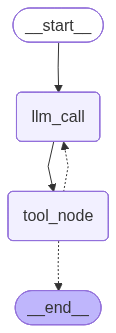

In [10]:
chart_agent = ChartAgent()
chart_agent.build_agent_graph()